In [8]:
import pandas as pd
import matplotlib.pyplot as plt

#load data
df = pd.read_csv("microbiology_cultures_cohort.csv")

#checks
print(df.columns)
print(df["organism"].unique()[:20])
print(df["antibiotic"].unique()[:20])
print(df["susceptibility"].unique())


Index(['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded',
       'order_time_jittered_utc', 'ordering_mode', 'culture_description',
       'was_positive', 'organism', 'antibiotic', 'susceptibility'],
      dtype='str')
<StringArray>
[   'KLEBSIELLA PNEUMONIAE',    'RHIZOBIUM RADIOBACTER',
    'SERRATIA LIQUEFACIENS',    'STAPHYLOCOCCUS AUREUS',
   'BREVIBACTERIUM SPECIES',   'ENTEROBACTER GERGOVIAE',
   'MYCOBACTERIUM CHELONAE',   'PROTEUS VULGARIS GROUP',
   'PSEUDOMONAS AERUGINOSA',   'STAPHYLOCOCCUS SPECIES',
  'ACINETOBACTER BAUMANNII',  'ENTEROCOCCUS RAFFINOSUS',
  'LACTOBACILLUS RHAMNOSUS',  'MYCOBACTERIUM ABSCESSUS',
  'STREPTOCOCCUS BOVIS GP.',  'STREPTOCOCCUS SANGUINIS',
 'BURKHOLDERIA CENOCEPACIA', 'BURKHOLDERIA MULTIVORANS',
 'CORYNEBACTERIUM ACCOLENS', 'CORYNEBACTERIUM STRIATUM']
Length: 20, dtype: str
<StringArray>
[                    'Ertapenem',                     'Meropenem',
                    'Ampicillin',                    'Cefotaxime',
                   

In [9]:
#data cleaning
#standardising text
df["organism"] = df["organism"].astype(str).str.upper().str.strip()
df["antibiotic"] = df["antibiotic"].astype(str).str.upper().str.strip()
df["susceptibility"] = df["susceptibility"].astype(str).str.upper().str.strip()

#overview - check
print("TOP ORGANISMS")
print(df["organism"].value_counts().head(20))

print("TOP ANTIBIOTICS")
print(df["antibiotic"].value_counts().head(20))

print("SUSCEPTIBILITY VALUES")
print(df["susceptibility"].value_counts())


#check for MRSA
mrsa_df = df[df["organism"] == "STAPHYLOCOCCUS AUREUS"]
print("Antibiotics tested for S. aureus:")
print(mrsa_df["antibiotic"].value_counts())
print("\nOxacillin susceptibility:")
print(
    mrsa_df[mrsa_df["antibiotic"].str.contains("OXA", na=False)]
    ["susceptibility"]
    .value_counts()
)
print("\nCefoxitin susceptibility:")
print(
    mrsa_df[mrsa_df["antibiotic"].str.contains("CEFOX", na=False)]
    ["susceptibility"]
    .value_counts()
)
print("\nExample MRSA rows:")
print(
    mrsa_df[
        (mrsa_df["antibiotic"].str.contains("OXA", na=False)) &
        (mrsa_df["susceptibility"].isin(["R","RESISTANT"]))
    ][["organism","antibiotic","susceptibility"]].head(10)
)


# VRE check

print("VRE CHECK (Enterococcus)")
vre_df = df[
    df["organism"].isin([
        "ENTEROCOCCUS FAECIUM",
        "ENTEROCOCCUS FAECALIS"
    ])
]
print("\nAntibiotics tested for Enterococcus:")
print(vre_df["antibiotic"].value_counts())
print("\nVancomycin susceptibility:")
print(
    vre_df[vre_df["antibiotic"].str.contains("VANCO", na=False)]
    ["susceptibility"]
    .value_counts()
)
print("\nExample VRE rows:")
print(
    vre_df[
        (vre_df["antibiotic"].str.contains("VANCO", na=False)) &
        (vre_df["susceptibility"].isin(["R","RESISTANT"]))
    ][["organism","antibiotic","susceptibility"]].head(10)
)

#CRE check
print("CRE CHECK (E.coli / Klebsiella)")
cre_df = df[
    df["organism"].isin([
        "ESCHERICHIA COLI",
        "KLEBSIELLA PNEUMONIAE"
    ])
]
print("\nAntibiotics tested for E. coli / Klebsiella:")
print(cre_df["antibiotic"].value_counts().head(30))
print("\nCarbapenem susceptibility counts:")
print(
    cre_df[
        cre_df["antibiotic"].isin([
            "MEROPENEM",
            "IMIPENEM",
            "ERTAPENEM"
        ])
    ]
    .groupby(["organism","antibiotic","susceptibility"])
    .size()
)
print("\nExample CRE rows:")
print(
    cre_df[
        (cre_df["antibiotic"].isin(["MEROPENEM","IMIPENEM","ERTAPENEM"])) &
        (cre_df["susceptibility"].isin(["R","RESISTANT"]))
    ][["organism","antibiotic","susceptibility"]].head(10)
)


TOP ORGANISMS
organism
ESCHERICHIA COLI                          874897
NULL                                      632308
KLEBSIELLA PNEUMONIAE                     151964
STAPHYLOCOCCUS AUREUS                      82519
PROTEUS MIRABILIS                          67938
ENTEROCOCCUS SPECIES                       64511
PSEUDOMONAS AERUGINOSA                     48959
MUCOID PSEUDOMONAS AERUGINOSA              33037
KLEBSIELLA OXYTOCA                         25066
ENTEROBACTER CLOACAE COMPLEX               24042
COAG NEGATIVE STAPHYLOCOCCUS               20866
STAPH AUREUS {MRSA}                        16674
PSEUDOMONAS AERUGINOSA (NON-MUCOID CF)     16327
CITROBACTER KOSERI                         16315
SERRATIA MARCESCENS                        15075
STREPTOCOCCUS AGALACTIAE (GROUP B)         12718
CITROBACTER FREUNDII COMPLEX               12598
KLEBSIELLA AEROGENES                       11295
MORGANELLA MORGANII                        10265
ZZZENTEROBACTER AEROGENES                   96

In [10]:
# the pool of data for MRSA raw data

mrsa_pos_ox_pool = df[
    (df["organism"] == "STAPHYLOCOCCUS AUREUS") &
    (df["antibiotic"] == "OXACILLIN") &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

mrsa_A_pool = df[
    (df["organism"] == "STAPHYLOCOCCUS AUREUS") &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S", "INTERMEDIATE", "I"]))
]

mrsa_B_ox_pool = df[
    (df["organism"] != "STAPHYLOCOCCUS AUREUS") &
    (df["antibiotic"] == "OXACILLIN") &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S"]))
]

mrsa_C_ox_pool = df[
    (df["organism"] != "STAPHYLOCOCCUS AUREUS") &
    (df["antibiotic"] == "OXACILLIN") &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

mrsa_D_pool = df[
    (df["organism"].str.contains("STAPHYLOCOCC", na=False)) &
    (df["organism"] != "STAPHYLOCOCCUS AUREUS")
]

mrsa_E_pool = df[
    ~(
        (df["organism"] == "STAPHYLOCOCCUS AUREUS") &
        (df["antibiotic"] == "OXACILLIN") &
        (df["susceptibility"].isin(["RESISTANT", "R"]))
    )
]

mrsa_pos_ox = mrsa_pos_ox_pool.sample(n=500, random_state=42)
mrsa_A = mrsa_A_pool.sample(n=100, random_state=42)
mrsa_B_ox = mrsa_B_ox_pool.sample(n=100, random_state=42)
mrsa_C_ox = mrsa_C_ox_pool.sample(n=100, random_state=42)
mrsa_D = mrsa_D_pool.sample(n=100, random_state=42)
mrsa_E = mrsa_E_pool.sample(n=100, random_state=42)

mrsa_pos_ox["label"] = "MRSA"
mrsa_A["label"] = "NOT_MRSA"
mrsa_B_ox["label"] = "NOT_MRSA"
mrsa_C_ox["label"] = "NOT_MRSA"
mrsa_D["label"] = "NOT_MRSA"
mrsa_E["label"] = "NOT_MRSA"

mrsa_pos_ox["neg_group"] = ""
mrsa_A["neg_group"] = "A"
mrsa_B_ox["neg_group"] = "B"
mrsa_C_ox["neg_group"] = "C"
mrsa_D["neg_group"] = "D"
mrsa_E["neg_group"] = "E"

MRSA_raw = pd.concat([
    mrsa_pos_ox,
    mrsa_A,
    mrsa_B_ox,
    mrsa_C_ox,
    mrsa_D,
    mrsa_E
], ignore_index=True)

MRSA_raw.to_csv("MRSA_raw.csv", index=False)

print("MRSA pools:")
print("pos_ox", len(mrsa_pos_ox_pool))
print("A", len(mrsa_A_pool))
print("B_ox", len(mrsa_B_ox_pool))
print("C_ox", len(mrsa_C_ox_pool))
print("D", len(mrsa_D_pool))
print("E", len(mrsa_E_pool))
print("Final MRSA_raw:", len(MRSA_raw))


# the pool of data for VRE raw data

vre_orgs = ["ENTEROCOCCUS FAECIUM", "ENTEROCOCCUS FAECALIS"]

vre_pos_pool = df[
    (df["organism"].isin(vre_orgs)) &
    (df["antibiotic"] == "VANCOMYCIN") &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

vre_A_pool = df[
    (df["organism"].isin(vre_orgs)) &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S", "INTERMEDIATE", "I"]))
]

vre_B_pool = df[
    (~df["organism"].isin(vre_orgs)) &
    (df["antibiotic"] == "VANCOMYCIN") &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S"]))
]

vre_C_pool = df[
    (~df["organism"].isin(vre_orgs)) &
    (df["antibiotic"] == "VANCOMYCIN") &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

vre_D_pool = df[
    df["organism"].str.contains("STAPHYLOCOCC|STREPTOCOCC", na=False)
]

vre_E_pool = df[
    ~(
        (df["organism"].isin(vre_orgs)) &
        (df["antibiotic"] == "VANCOMYCIN") &
        (df["susceptibility"].isin(["RESISTANT", "R"]))
    )
]

vre_pos = vre_pos_pool.sample(n=100, random_state=42)
vre_A = vre_A_pool.sample(n=20, random_state=42)
vre_B = vre_B_pool.sample(n=20, random_state=42)
vre_C = vre_C_pool.sample(n=20, random_state=42)
vre_D = vre_D_pool.sample(n=20, random_state=42)
vre_E = vre_E_pool.sample(n=20, random_state=42)

vre_pos["label"] = "VRE"
vre_A["label"] = "NOT_VRE"
vre_B["label"] = "NOT_VRE"
vre_C["label"] = "NOT_VRE"
vre_D["label"] = "NOT_VRE"
vre_E["label"] = "NOT_VRE"

vre_pos["neg_group"] = ""
vre_A["neg_group"] = "A"
vre_B["neg_group"] = "B"
vre_C["neg_group"] = "C"
vre_D["neg_group"] = "D"
vre_E["neg_group"] = "E"

VRE_raw = pd.concat([
    vre_pos,
    vre_A,
    vre_B,
    vre_C,
    vre_D,
    vre_E
], ignore_index=True)

VRE_raw.to_csv("VRE_raw.csv", index=False)

print("\nVRE pools:")
print("pos", len(vre_pos_pool))
print("A", len(vre_A_pool))
print("B", len(vre_B_pool))
print("C", len(vre_C_pool))
print("D", len(vre_D_pool))
print("E", len(vre_E_pool))
print("Final VRE_raw:", len(VRE_raw))


# the pool of data for CRE raw data

cre_orgs = ["ESCHERICHIA COLI", "KLEBSIELLA PNEUMONIAE"]
cre_drugs = ["MEROPENEM", "IMIPENEM", "ERTAPENEM"]

cre_pos_pool = df[
    (df["organism"].isin(cre_orgs)) &
    (df["antibiotic"].isin(cre_drugs)) &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

cre_A_pool = df[
    (df["organism"].isin(cre_orgs)) &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S", "INTERMEDIATE", "I"]))
]

cre_B_pool = df[
    (~df["organism"].isin(cre_orgs)) &
    (df["antibiotic"].isin(cre_drugs)) &
    (df["susceptibility"].isin(["SUSCEPTIBLE", "S"]))
]

cre_C_pool = df[
    (~df["organism"].isin(cre_orgs)) &
    (df["antibiotic"].isin(cre_drugs)) &
    (df["susceptibility"].isin(["RESISTANT", "R"]))
]

cre_D_pool = df[
    df["organism"].str.contains("ENTEROBACTER|CITROBACTER|PROTEUS", na=False)
]

cre_E_pool = df[
    ~(
        (df["organism"].isin(cre_orgs)) &
        (df["antibiotic"].isin(cre_drugs)) &
        (df["susceptibility"].isin(["RESISTANT", "R"]))
    )
]

cre_pos = cre_pos_pool.sample(n=100, random_state=42)
cre_A = cre_A_pool.sample(n=20, random_state=42)
cre_B = cre_B_pool.sample(n=20, random_state=42)
cre_C = cre_C_pool.sample(n=20, random_state=42)
cre_D = cre_D_pool.sample(n=20, random_state=42)
cre_E = cre_E_pool.sample(n=20, random_state=42)

cre_pos["label"] = "CRE"
cre_A["label"] = "NOT_CRE"
cre_B["label"] = "NOT_CRE"
cre_C["label"] = "NOT_CRE"
cre_D["label"] = "NOT_CRE"
cre_E["label"] = "NOT_CRE"

cre_pos["neg_group"] = ""
cre_A["neg_group"] = "A"
cre_B["neg_group"] = "B"
cre_C["neg_group"] = "C"
cre_D["neg_group"] = "D"
cre_E["neg_group"] = "E"

CRE_raw = pd.concat([
    cre_pos,
    cre_A,
    cre_B,
    cre_C,
    cre_D,
    cre_E
], ignore_index=True)

CRE_raw.to_csv("CRE_raw.csv", index=False)

print("\nCRE pools:")
print("pos", len(cre_pos_pool))
print("A", len(cre_A_pool))
print("B", len(cre_B_pool))
print("C", len(cre_C_pool))
print("D", len(cre_D_pool))
print("E", len(cre_E_pool))
print("Final CRE_raw:", len(CRE_raw))


MRSA pools:
pos_ox 936
A 64453
B_ox 1384
C_ox 2895
D 23522
E 2240114
Final MRSA_raw: 1000

VRE pools:
pos 179
A 8896
B 22136
C 513
D 139254
E 2240871
Final VRE_raw: 200

CRE pools:
pos 102
A 882775
B 34052
C 3355
D 147316
E 2240948
Final CRE_raw: 200


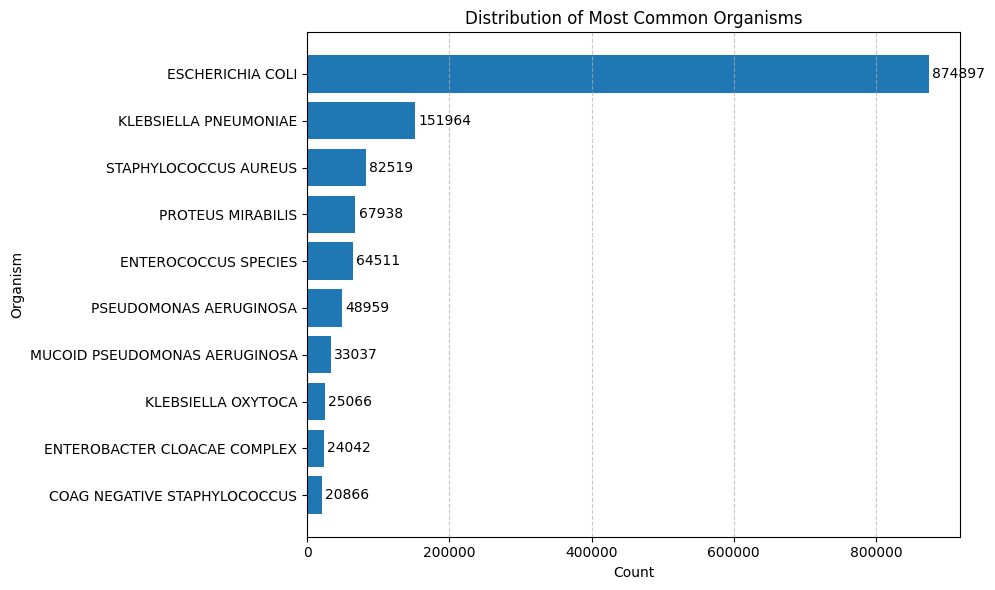

In [11]:
#graph for organism distribution
top_org = df[df["organism"] != "NULL"]["organism"].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_org.index[::-1], top_org.values[::-1])

plt.title("Distribution of Most Common Organisms")
plt.xlabel("Count")
plt.ylabel("Organism")
plt.grid(axis="x", linestyle="--", alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(top_org.values)*0.005, bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va="center")

plt.tight_layout()
plt.savefig("organism_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

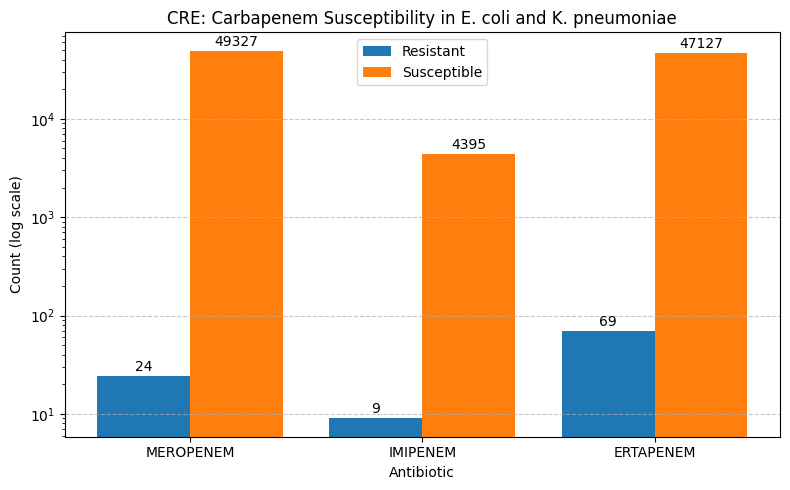

In [12]:
#cre graph
cre = df[
    (df["organism"].isin(["ESCHERICHIA COLI", "KLEBSIELLA PNEUMONIAE"])) &
    (df["antibiotic"].isin(["MEROPENEM", "IMIPENEM", "ERTAPENEM"])) &
    (df["susceptibility"].isin(["RESISTANT", "SUSCEPTIBLE"]))
]

cre_counts = cre.groupby(["antibiotic", "susceptibility"]).size().unstack(fill_value=0)
cre_counts = cre_counts.reindex(index=["MEROPENEM", "IMIPENEM", "ERTAPENEM"], fill_value=0)
cre_counts = cre_counts.reindex(columns=["RESISTANT", "SUSCEPTIBLE"], fill_value=0)

x = range(len(cre_counts))

plt.figure(figsize=(8, 5))
bars1 = plt.bar([i - 0.2 for i in x], cre_counts["RESISTANT"], width=0.4, label="Resistant")
bars2 = plt.bar([i + 0.2 for i in x], cre_counts["SUSCEPTIBLE"], width=0.4, label="Susceptible")

plt.xticks(x, cre_counts.index)
plt.yscale("log")
plt.title("CRE: Carbapenem Susceptibility in E. coli and K. pneumoniae")
plt.xlabel("Antibiotic")
plt.ylabel("Count (log scale)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height * 1.05,
                     f"{int(height)}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("cre_eda.png", dpi=300, bbox_inches="tight")
plt.show()

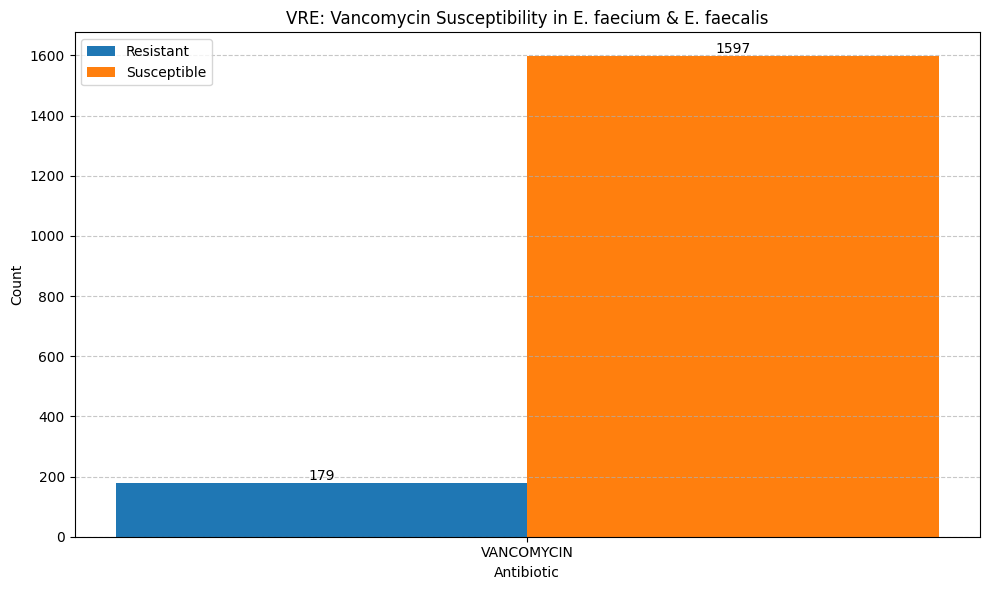

In [13]:
#vre count graph
vre_orgs = ["ENTEROCOCCUS FAECIUM", "ENTEROCOCCUS FAECALIS"]

vre = df[
    (df["organism"].isin(vre_orgs)) &
    (df["antibiotic"] == "VANCOMYCIN") &
    (df["susceptibility"].isin(["RESISTANT", "SUSCEPTIBLE"]))
]

vre_counts = vre.groupby(["antibiotic", "susceptibility"]).size().unstack(fill_value=0)

vre_counts = vre_counts.reindex(index=["VANCOMYCIN"], fill_value=0)
vre_counts = vre_counts.reindex(columns=["RESISTANT", "SUSCEPTIBLE"], fill_value=0)

x = range(len(vre_counts))

plt.figure(figsize=(10, 6))
bars1 = plt.bar([i - 0.2 for i in x], vre_counts["RESISTANT"], width=0.4, label="Resistant")
bars2 = plt.bar([i + 0.2 for i in x], vre_counts["SUSCEPTIBLE"], width=0.4, label="Susceptible")

plt.xticks(x, vre_counts.index)
plt.title("VRE: Vancomycin Susceptibility in E. faecium & E. faecalis")
plt.xlabel("Antibiotic")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                 f"{int(height)}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("vre_eda_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

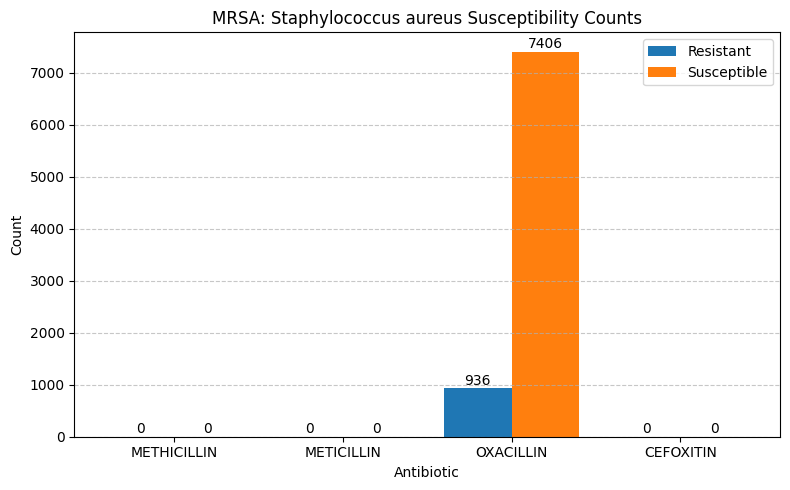

In [14]:
#mrsa count graph
mrsa_antibiotics = ["METHICILLIN", "METICILLIN", "OXACILLIN", "CEFOXITIN"]

mrsa = df[
    (df["organism"] == "STAPHYLOCOCCUS AUREUS") &
    (df["antibiotic"].isin(mrsa_antibiotics)) &
    (df["susceptibility"].isin(["RESISTANT", "SUSCEPTIBLE"]))
]

mrsa_counts = (
    mrsa.groupby(["antibiotic", "susceptibility"])
    .size()
    .unstack(fill_value=0)
)

# Force all antibiotics to appear even when 0
mrsa_counts = mrsa_counts.reindex(index=mrsa_antibiotics, fill_value=0)
mrsa_counts = mrsa_counts.reindex(columns=["RESISTANT", "SUSCEPTIBLE"], fill_value=0)

x = range(len(mrsa_counts))

plt.figure(figsize=(8, 5))

bars1 = plt.bar([i - 0.2 for i in x], mrsa_counts["RESISTANT"], width=0.4, label="Resistant")
bars2 = plt.bar([i + 0.2 for i in x], mrsa_counts["SUSCEPTIBLE"], width=0.4, label="Susceptible")

plt.xticks(x, mrsa_counts.index)
plt.title("MRSA: Staphylococcus aureus Susceptibility Counts")
plt.xlabel("Antibiotic")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 5,
                 f"{int(height)}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("mrsa_multi_fixed.png", dpi=300, bbox_inches="tight")
plt.show()